In [1]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_curve, roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import recall_score, confusion_matrix, precision_score, f1_score, accuracy_score, classification_report

In [2]:
df1 = pd.read_csv("../dataset/train.csv")
X_train = df1.drop(columns = ['Churn'])
y_train = df1['Churn'].values
df2 = pd.read_csv("../dataset/test.csv")
X_test = df2.drop(columns = ['Churn'])
y_test = df2['Churn'].values

Random Forest Report (100 trees):
               precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



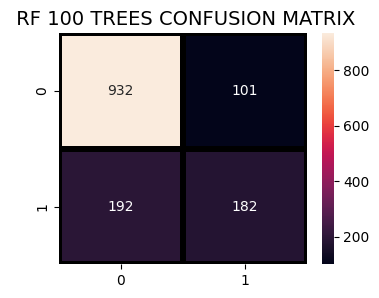

In [7]:
#nhai lại code bên file simple models
#bản này mình đang để số cây là 100 nhé
rf_model = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42)
#train
rf_model.fit(X_train, y_train)
#test
y_pred_100 = rf_model.predict(X_test)
#kq
print("Random Forest Report (100 trees):\n", classification_report(y_test, y_pred_100))
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_100), annot=True,fmt = "d",linecolor="k",linewidths=3)
plt.title(" RF 100 TREES CONFUSION MATRIX",fontsize=14)
plt.show()

Random Forest Report (500 trees):
               precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.51      0.57       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.72      1407
weighted avg       0.78      0.79      0.79      1407



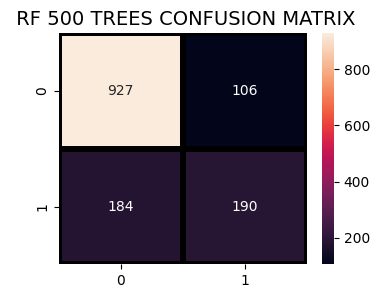

Random Forest Report (1000 trees):
               precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.51      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.72      1407
weighted avg       0.78      0.79      0.78      1407



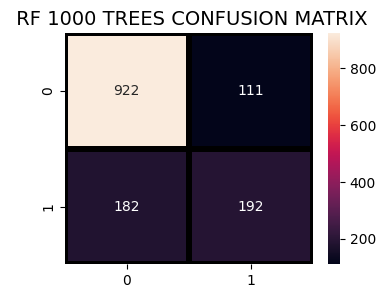

In [ ]:
#tăng số cây lên thì model ổn định hơn, precision với recall ngon hơn, nhưng chạy lâu hơn
#data mình bé thì lâu hơn tí ksao
#500 cây
rf_model = RandomForestClassifier(n_estimators=500, max_depth=None, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_500 = rf_model.predict(X_test)
print("Random Forest Report (500 trees):\n", classification_report(y_test, y_pred_500))
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_500), annot=True,fmt = "d",linecolor="k",linewidths=3)
plt.title(" RF 500 TREES CONFUSION MATRIX",fontsize=14)
plt.show()

#1000 cây luôn đê !
rf_model = RandomForestClassifier(n_estimators=1000, max_depth=None, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_1000 = rf_model.predict(X_test)
print("Random Forest Report (1000 trees):\n", classification_report(y_test, y_pred_1000))
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_1000), annot=True,fmt = "d",linecolor="k",linewidths=3)
plt.title(" RF 1000 TREES CONFUSION MATRIX",fontsize=14)
plt.show()

#thôi chốt lại là 500 cây nhé, 1000 hiệu quả cũng tương tự mà tgian chạy lâu hơn, 100 thì bỏ sót nhiều churn


-----Random Forest with 500 tree and max_depth=5-----
              precision    recall  f1-score   support

           0       0.92      0.74      0.82      1033
           1       0.53      0.82      0.64       374

    accuracy                           0.76      1407
   macro avg       0.72      0.78      0.73      1407
weighted avg       0.81      0.76      0.77      1407



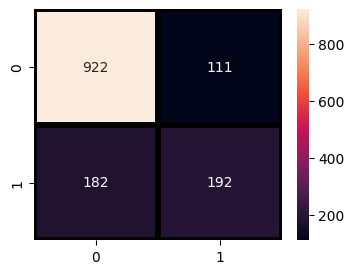


-----Random Forest with 500 tree and max_depth=10-----
              precision    recall  f1-score   support

           0       0.89      0.81      0.85      1033
           1       0.58      0.73      0.64       374

    accuracy                           0.78      1407
   macro avg       0.73      0.77      0.74      1407
weighted avg       0.81      0.78      0.79      1407



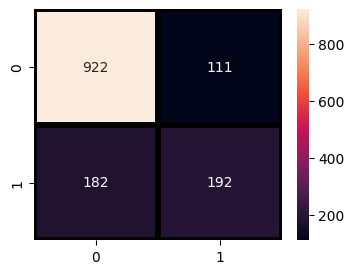


-----Random Forest with 500 tree and max_depth=20-----
              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1033
           1       0.65      0.49      0.56       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



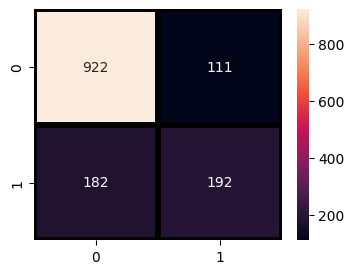

In [ ]:
#cách tiếp theo là giới hạn max depth (bth để là None)
#vì nếu không giới hạn, sẽ ptrien rất sâu và bị overfit, đặc biệt với dl bị lệch ntn
for depth in [5, 10, 20]:
    rf = RandomForestClassifier(
        n_estimators=500,
        max_depth=depth,
        random_state=42,
        class_weight='balanced'
    )
    rf.fit(X_train, y_train)
    y_pred_numtree = rf.predict(X_test)
    
    print(f"\n-----Random Forest with 500 tree and max_depth={depth}-----")
    print(classification_report(y_test, y_pred_numtree))
    plt.figure(figsize=(4,3))
    sns.heatmap(confusion_matrix(y_test, y_pred_1000), annot=True,fmt = "d",linecolor="k",linewidths=3)
    plt.show()

#ncl depth 5 hơi tham, còn 20 hoặc none thì bỏ sót nhiều, chọn 10 nhé

             Feature  Importance
14          Contract    0.171060
4             tenure    0.149446
18      TotalCharges    0.137240
17    MonthlyCharges    0.131339
11       TechSupport    0.071867
8     OnlineSecurity    0.065335
7    InternetService    0.048090
16     PaymentMethod    0.043384
9       OnlineBackup    0.026142
10  DeviceProtection    0.023397


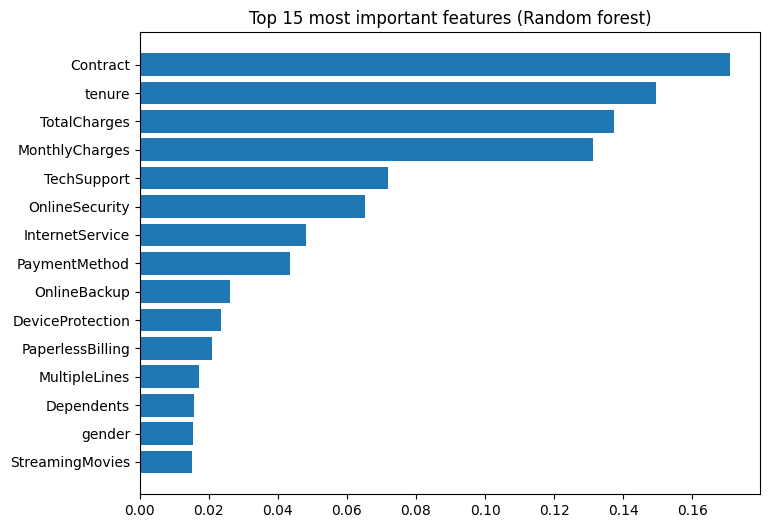

In [12]:
#thử cách feature importance nè
#set up lại mô hình theo tất cả những cái đã chọn (500 cây, depth 10, class weight)
rf = RandomForestClassifier(n_estimators=500, max_depth=10, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

#lấy ft importance
importances = rf.feature_importances_
feature_names = X_train.columns
#tạo df để luyện riêng
feat_imp = pd.DataFrame({'Feature': feature_names,'Importance': importances}).sort_values(by='Importance', ascending=False)
#in thử 10 ft qtrng nhất nhé. t nghĩ 10 là cũng đủ dùng rồi
print(feat_imp.head(10))
#xông xênh thì vẽ hẳn 15 luôn
plt.figure(figsize=(8,6))
plt.barh(feat_imp['Feature'][:15], feat_imp['Importance'][:15])
plt.gca().invert_yaxis()
plt.title("Top 15 most important features (Random forest)")
plt.show()

Random forest with top 10 features:
              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1033
           1       0.57      0.73      0.64       374

    accuracy                           0.78      1407
   macro avg       0.73      0.77      0.74      1407
weighted avg       0.81      0.78      0.79      1407



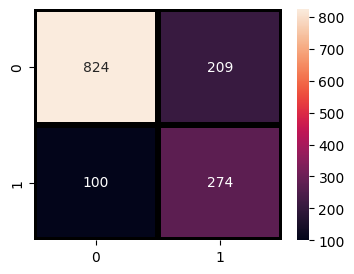

In [14]:
#thế nhé, múa lại với 10 ft
top_features = feat_imp['Feature'].head(10).values

X_train_top = X_train[top_features]
X_test_top = X_test[top_features]
#lại với top 10 ft nè
rf_top = RandomForestClassifier(n_estimators=500, max_depth=10, random_state=42, class_weight='balanced'
)
rf_top.fit(X_train_top, y_train)

y_pred_top = rf_top.predict(X_test_top)

print("Random forest with top 10 features:")
print(classification_report(y_test, y_pred_top))
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_top), annot=True,fmt = "d",linecolor="k",linewidths=3)
plt.show()


-----Random Forest with top Top 5 features-----
              precision    recall  f1-score   support

           0       0.89      0.79      0.84      1033
           1       0.55      0.73      0.63       374

    accuracy                           0.77      1407
   macro avg       0.72      0.76      0.73      1407
weighted avg       0.80      0.77      0.78      1407



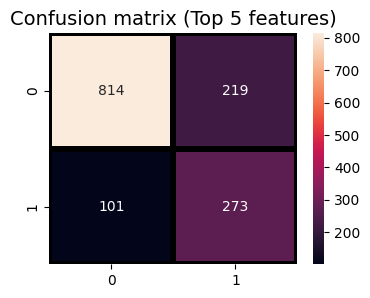


-----Random Forest with top Top 15 features-----
              precision    recall  f1-score   support

           0       0.88      0.81      0.84      1033
           1       0.57      0.70      0.63       374

    accuracy                           0.78      1407
   macro avg       0.73      0.76      0.74      1407
weighted avg       0.80      0.78      0.79      1407



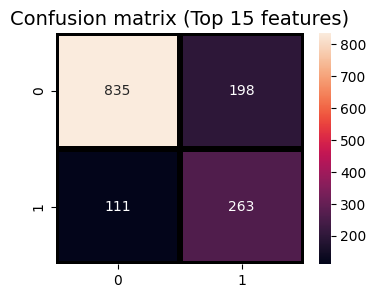

In [ ]:
#thra 10 có vẻ đủ rồi nhưng t nghịch thêm =)))
#top 5 thì hơi tham còn top 15 thì thêm biến vào mà hiệu năng chả tăng, nên thôi
top5_features = feat_imp['Feature'].head(5).values
top15_features = feat_imp['Feature'].head(15).values
#hàm train nè
def train_and_evaluate(features, label):
    X_train_sub = X_train[features]
    X_test_sub = X_test[features]
    
    rf = RandomForestClassifier(n_estimators=500, max_depth=10, random_state=42, class_weight='balanced')
    rf.fit(X_train_sub, y_train)
    y_pred = rf.predict(X_test_sub)
    
    print(f"\n-----Random Forest with top {label} features-----")
    print(classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", linecolor="k", linewidths=3)
    plt.title(f"Confusion matrix ({label} features)", fontsize=14)
    plt.show()
#chạy nè
train_and_evaluate(top5_features, "Top 5")
train_and_evaluate(top15_features, "Top 15")

Best parameters: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 500}

Hyperparameters tuning:
              precision    recall  f1-score   support

           0       0.90      0.79      0.84      1033
           1       0.56      0.76      0.65       374

    accuracy                           0.78      1407
   macro avg       0.73      0.77      0.74      1407
weighted avg       0.81      0.78      0.79      1407



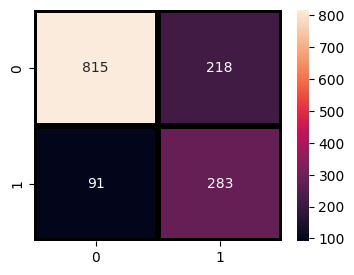

In [ ]:
#trò này thì giống cái cell cuối bên file logistic =)))
from sklearn.model_selection import GridSearchCV

param_grid = {'n_estimators': [500], 'max_depth': [10], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4], 'class_weight': ['balanced']}

rf = RandomForestClassifier(random_state=42)
grid = GridSearchCV(rf, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
best_rf = grid.best_estimator_

y_pred_para = best_rf.predict(X_test)

print("\nHyperparameters tuning:")
print(classification_report(y_test, y_pred_para))
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_para), annot=True,fmt = "d",linecolor="k",linewidths=3)
plt.show()
#cả recall lẫn f1 của churn đều tăng, tức là bắt đúng nhiều hơn, bỏ sót ít hơn, quá đã